# LACT 单像素恒星强度干涉：完整波形 GLS 模拟与重建

本 Notebook 从仪器参数和天体真值开始，依次计算连续理论可见度、32 台望远镜的分时段 UV 覆盖、单像素短波形相关、波形标定的广义最小二乘（GLS）观测量，以及无相位图像重建。正文、输出说明和代码注释使用中文；论文图片内部统一使用英文。

所有长曝光结果均由短波形标定出的完整相关峰模板与协方差产生。程序没有创建无法存储的数小时连续 ADC 数组，也没有直接在理论真值上随意添加误差。

## 1. 环境、随机种子与绘图规范

固定随机种子保证结果可复现。图片采用白底、内向刻度、有限配色和共享坐标轴；每张组合图只回答一个问题。

In [1]:
from dataclasses import replace
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, TwoSlopeNorm
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.optimize import minimize

ROOT = Path.cwd().resolve()
if not (ROOT / "python" / "sii_unified.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "python"))

from sii_unified import (
    BinarySource, EllipseSource, Instrument, Observation, TransitSource,
    detected_star_rate_hz, generate_uvw, load_measured_spe_template,
    load_optical_timing_mixture, make_fast_spe_template, render_pe_waveform,
    reconstruct_uv, run_sii_pipeline, segment_averaged_visibility2,
    simulate_hbt_primary_pe,
    simulate_waveform_gls_calibration, source_visibility,
    waveform_cross_correlation, waveform_gls_weights,
)

SEED = 20260903
FIGURE_DIR = ROOT / "docs" / "sii_workflow_figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# 简洁的论文绘图基线；图内只使用英文。
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 240,
    "font.family": "DejaVu Sans", "font.size": 9,
    "axes.linewidth": 0.8, "axes.labelsize": 9,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "legend.frameon": False, "legend.fontsize": 8,
    "image.cmap": "magma",
})

BLUE = "#3B6FB6"
ORANGE = "#D97732"
GOLD = "#C9A227"
INK = "#242424"
LIGHT = "#C7D7EE"
MAS_TO_RAD = np.pi / (180 * 3600 * 1000)

## 2. 实验与仪器参数

下表由仓库中 main 程序使用的光学、SiPM、SPE、NSB 和阵列配置读取。标为零的硬件系统误差不是已测得为零，而是当前缺少标定、按约定关闭。

In [2]:
instrument = Instrument.from_repository(ROOT)
layout_path = ROOT / "configs" / "arrays" / "layout_0803_reco32_coordinates.csv"
layout = pd.read_csv(layout_path)
reference_source = BinarySource(ab_magnitude=2.0)
reference_observation = Observation(hours_per_night=6.0, segment_s=1200.0)

instrument_rows = [
    ("Telescope count", len(layout), "configuration", "32-telescope layout"),
    ("Central wavelength", instrument.wavelength_nm, "nm", "configuration"),
    ("Optical bandwidth", instrument.optical_width_nm, "nm", "scenario assumption"),
    ("Effective mirror area", instrument.effective_area_m2, "m2", "main configuration"),
    ("End-to-end throughput", instrument.throughput, "", "main optical response"),
    ("Detected NSB rate", instrument.detected_nsb_rate_hz / 1e6, "MHz pixel-1", "main spectrum"),
    ("ADC sample interval", instrument.sample_width_ns, "ns", "main electronics"),
    ("One-sided bandwidth", instrument.electronics_bandwidth_hz / 1e6, "MHz", "Nyquist bound"),
    ("SPE charge factor", instrument.excess_noise_factor, "", "measured samples"),
    ("Microcell recovery", instrument.microcell_recovery_time_ns, "ns", "configured value"),
    ("Electronic noise RMS", instrument.electronic_noise_rms_mv, "mV", "missing; disabled"),
    ("Dark-count rate", instrument.dark_count_rate_hz / 1e6, "MHz pixel-1", "missing; disabled"),
    ("Residual timing RMS", instrument.residual_timing_rms_ns, "ns", "missing; disabled"),
]
instrument_table = pd.DataFrame(
    instrument_rows, columns=["Parameter", "Value", "Unit", "Source/status"])
display(instrument_table)

,Parameter,Value,Unit,Source/status
0,Telescope count,32.000000,configuration,32-telescope layout
1,Central wavelength,400.000000,nm,configuration
2,Optical bandwidth,2.000000,nm,scenario assumption
3,Effective mirror area,24.576860,m2,main configuration
4,End-to-end throughput,0.188847,,main optical response
5,Detected NSB rate,70.527457,MHz pixel-1,main spectrum
6,ADC sample interval,4.000000,ns,main electronics
7,One-sided bandwidth,125.000000,MHz,Nyquist bound
8,SPE charge factor,1.016142,,measured samples
9,Microcell recovery,10.000000,ns,configured value


## 3. 天体模型与连续理论 UV 平面

归一化天空亮度记为 (I(l,m))，其二维傅里叶变换是复可见度

\[
V(u,v)=\iint I(l,m)e^{-2\pi i(ul+vm)}\,dl\,dm.
\]

强度干涉测量的是 (P(u,v)=|V(u,v)|^2)。本节先展示默认双星的天空真值和连续理论 (P)，尚未加入望远镜采样与噪声。

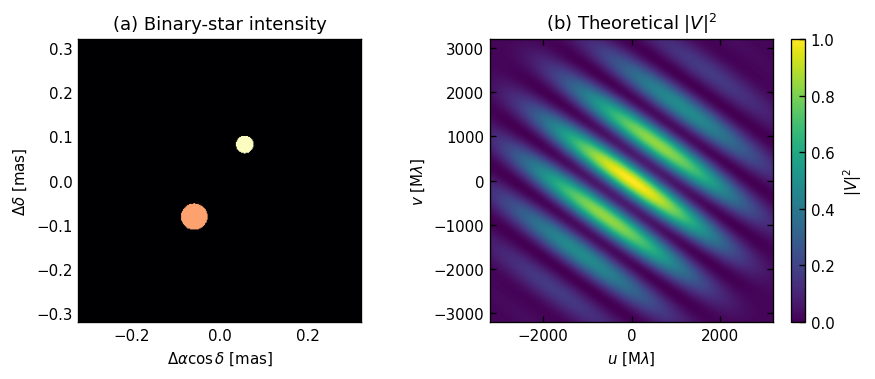

In [3]:
def sky_image(source_case, source, theta_mas):
    # 在显示网格上生成归一化天体真值；解析可见度不依赖此像素化。
    yy, xx = np.meshgrid(theta_mas, theta_mas, indexing="ij")
    image = np.zeros_like(xx)
    if source_case == "binary":
        angle = np.deg2rad(source.position_angle_deg)
        dx = 0.5 * source.separation_mas * np.sin(angle)
        dy = 0.5 * source.separation_mas * np.cos(angle)
        first = (xx + dx) ** 2 + (yy + dy) ** 2 <= (source.primary_diameter_mas / 2) ** 2
        second = (xx - dx) ** 2 + (yy - dy) ** 2 <= (source.secondary_diameter_mas / 2) ** 2
        image[first] = 1.0 / max(first.sum(), 1)
        image[second] += source.flux_ratio_secondary_to_primary / max(second.sum(), 1)
    elif source_case == "ellipse":
        angle = np.deg2rad(source.position_angle_deg)
        major = xx * np.sin(angle) + yy * np.cos(angle)
        minor = xx * np.cos(angle) - yy * np.sin(angle)
        mask = (major / (source.major_diameter_mas / 2)) ** 2 + (minor / (source.minor_diameter_mas / 2)) ** 2 <= 1
        image[mask] = 1.0
    elif source_case == "transit":
        star = xx**2 + yy**2 <= (source.stellar_diameter_mas / 2) ** 2
        planet = ((xx - source.planet_east_offset_mas) ** 2
                  + (yy - source.planet_north_offset_mas) ** 2
                  <= (source.planet_diameter_mas / 2) ** 2)
        image[star & ~planet] = 1.0
    else:
        raise ValueError(source_case)
    return image / image.sum()


def power_grid(source_case, source, limit_mlambda, points=301):
    spatial = np.linspace(-limit_mlambda, limit_mlambda, points) * 1e6
    vv, uu = np.meshgrid(spatial, spatial, indexing="ij")
    power = np.abs(source_visibility(uu, vv, source, source_case)) ** 2
    return spatial / 1e6, power


theta_display = np.linspace(-0.32, 0.32, 321)
binary_sky = sky_image("binary", reference_source, theta_display)
uvw_6h = generate_uvw(layout, reference_observation, instrument)
uv_limit = 1.05 * np.hypot(uvw_6h.u_lambda, uvw_6h.v_lambda).max() / 1e6
uv_axis, binary_power = power_grid("binary", reference_source, uv_limit)

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.05), constrained_layout=True)
extent_sky = [theta_display[0], theta_display[-1], theta_display[0], theta_display[-1]]
axes[0].imshow(binary_sky, origin="lower", extent=extent_sky, cmap="magma")
axes[0].set(xlabel=r"$\Delta\alpha\cos\delta$ [mas]", ylabel=r"$\Delta\delta$ [mas]", title="(a) Binary-star intensity")
power_artist = axes[1].imshow(binary_power, origin="lower",
    extent=[uv_axis[0], uv_axis[-1], uv_axis[0], uv_axis[-1]],
    cmap="viridis", vmin=0, vmax=1)
axes[1].set(xlabel=r"$u$ [M$\lambda$]", ylabel=r"$v$ [M$\lambda$]", title=r"(b) Theoretical $|V|^2$")
fig.colorbar(power_artist, ax=axes[1], label=r"$|V|^2$")
for axis in axes:
    axis.set_aspect("equal")
fig.savefig(FIGURE_DIR / "10_source_and_theoretical_uv.png", bbox_inches="tight")
plt.show()

## 4. 32 台望远镜的分时段 UV 覆盖

望远镜位置给出物理基线，源方向与地球自转把基线投影到 ​(u,v,w)​。下面比较瞬时20分钟段、2小时和6小时的覆盖。图中同时绘制 ​((u,v))​ 与 ​((-u,-v))​，但负基线不是额外的独立测量。

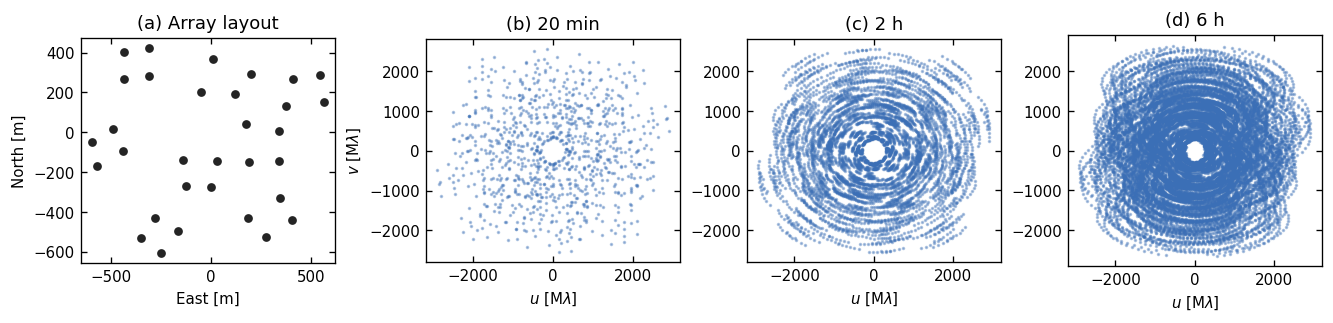

,Duration,Independent measurements,Displayed points including conjugates,Maximum projected baseline [m]
0,20 min,496,992,1214.69
1,2 h,2976,5952,1219.19
2,6 h,8928,17856,1219.19


In [4]:
coverage_observations = {
    "20 min": Observation(hours_per_night=1/3, segment_s=1200.0),
    "2 h": Observation(hours_per_night=2.0, segment_s=1200.0),
    "6 h": reference_observation,
}
coverage = {label: generate_uvw(layout, obs, instrument)
            for label, obs in coverage_observations.items()}

fig, axes = plt.subplots(1, 4, figsize=(11.0, 2.75), constrained_layout=True)
axes[0].scatter(layout.east_m, layout.north_m, s=18, c=INK)
axes[0].set(xlabel="East [m]", ylabel="North [m]", title="(a) Array layout")
axes[0].set_aspect("equal")
for panel, (label, frame) in enumerate(coverage.items(), start=1):
    x = frame.u_lambda.to_numpy() / 1e6
    y = frame.v_lambda.to_numpy() / 1e6
    axes[panel].scatter(np.r_[x, -x], np.r_[y, -y], s=1.2, c=BLUE, alpha=0.38, rasterized=True)
    axes[panel].set(xlabel=r"$u$ [M$\lambda$]", title=f"({chr(97+panel)}) {label}")
    axes[panel].set_aspect("equal")
    if panel == 1:
        axes[panel].set_ylabel(r"$v$ [M$\lambda$]")
fig.savefig(FIGURE_DIR / "11_array_and_uv_coverage.png", bbox_inches="tight")
plt.show()

coverage_table = pd.DataFrame([
    {"Duration": label, "Independent measurements": len(frame),
     "Displayed points including conjugates": 2 * len(frame),
     "Maximum projected baseline [m]": frame.projected_baseline_m.max()}
    for label, frame in coverage.items()
])
display(coverage_table.round(2))

## 5. 用完整短波形标定 GLS 测量

每台望远镜的单像素数据由恒星光电子、独立NSB、光学到达时间核、实测SPE和微单元恢复共同生成。对两条ADC波形计算多个时间延迟处的互相关向量，再由已知注入和零相关样本标定峰模板及噪声协方差。模板训练时增强相关对数仅用于降低Monte Carlo成本，最终长曝光协方差仍按物理零信号记录确定。

In [5]:
# 暗源需要更高的训练注入倍率；它不会改变最终物理SNR。
calibration_settings = {
    2.0: dict(hbt_pair_rate_scale=10_000.0, seed=SEED + 2),
    3.0: dict(hbt_pair_rate_scale=30_000.0, seed=SEED + 3),
    4.0: dict(hbt_pair_rate_scale=100_000.0, seed=SEED + 4),
    5.0: dict(hbt_pair_rate_scale=300_000.0, seed=SEED + 5),
}
calibrations = {}
calibration_diagnostics = {}
for magnitude, settings in calibration_settings.items():
    calibration, diagnostics = simulate_waveform_gls_calibration(
        instrument, source_ab_magnitude=magnitude,
        null_records=1024, signal_records=256,
        block_duration_ns=20_000.0, max_lag_ns=200.0,
        **settings)
    calibrations[magnitude] = calibration
    calibration_diagnostics[magnitude] = diagnostics

calibration_table = []
for magnitude, calibration in calibrations.items():
    _, sigma_20min = waveform_gls_weights(calibration, 1200.0)
    diagnostics = calibration_diagnostics[magnitude]
    calibration_table.append({
        "m_AB": magnitude,
        "Detected star rate [MHz]": calibration.star_rate_hz / 1e6,
        "Physical HBT pair rate [s-1]": diagnostics["physical_hbt_pair_rate_hz"],
        "Response closure": diagnostics["validation_response_closure"],
        "sigma_P (20 min)": sigma_20min,
    })
calibration_table = pd.DataFrame(calibration_table)
display(calibration_table.round(4))

,m_AB,Detected star rate [MHz],Physical HBT pair rate [s-1],Response closure,sigma_P (20 min)
0,2.0,201.5476,4563.5881,1.0013,0.1742
1,3.0,80.2375,723.2800,0.9725,0.6387
2,4.0,31.9431,114.6321,0.9860,2.7135
3,5.0,12.7168,18.1680,1.0323,13.5773


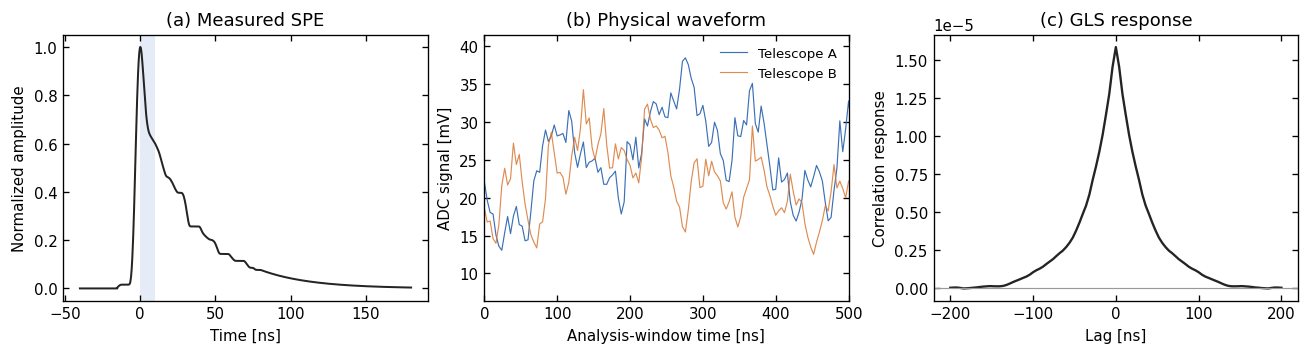

2 us有效窗内期望的物理HBT相关对：0.0091
20 us标定块外推到20 min时的 sigma_P：0.1742


In [6]:
reference_calibration = calibrations[2.0]
reference_diagnostics = calibration_diagnostics[2.0]
spe_time, spe_voltage = load_measured_spe_template(instrument.spe_template_path)
timing = load_optical_timing_mixture(instrument.optical_timing_kernel_path)
padding_ns = reference_diagnostics["padding_ns"]

# 2微秒物理记录用于显示真实波形；padding只供卷积，相关只使用有效窗。
rng = np.random.default_rng(SEED + 50)
physical_hits, physical_meta = simulate_hbt_primary_pe(
    rng, 2_000.0, reference_calibration.star_rate_hz,
    reference_calibration.background_rate_hz, 1.0, instrument,
    optical_timing_mixture=timing, padding_ns=padding_ns)
waveforms = []
for telescope_id in (0, 1):
    times = physical_hits.loc[physical_hits.telescope_id == telescope_id, "time_ns"].to_numpy()
    waveforms.append(render_pe_waveform(
        rng, times, 2_000.0, instrument,
        template=(spe_time, spe_voltage))["adc_mv"])
sample_time = np.arange(len(waveforms[0])) * instrument.sample_width_ns
lags, physical_correlation = waveform_cross_correlation(
    waveforms[0], waveforms[1], instrument.sample_width_ns, 200.0)
_, sigma_block = waveform_gls_weights(reference_calibration, reference_calibration.block_duration_s)

fig, axes = plt.subplots(1, 3, figsize=(10.8, 2.85), constrained_layout=True)
axes[0].plot(spe_time, spe_voltage / np.max(np.abs(spe_voltage)), color=INK, lw=1.2)
axes[0].axvspan(0, 10, color=LIGHT, alpha=0.45, lw=0)
axes[0].set(xlabel="Time [ns]", ylabel="Normalized amplitude", title="(a) Measured SPE")
axes[1].plot(sample_time, waveforms[0], color=BLUE, lw=0.7, label="Telescope A")
axes[1].plot(sample_time, waveforms[1], color=ORANGE, lw=0.7, alpha=0.85, label="Telescope B")
axes[1].set_xlim(0, 500)
axes[1].set(xlabel="Analysis-window time [ns]", ylabel="ADC signal [mV]", title="(b) Physical waveform")
axes[1].legend(loc="upper right")
peak = reference_calibration.peak_per_visibility2
axes[2].plot(reference_calibration.lags_ns, peak, color=INK, lw=1.4, label=r"Response $k(\tau)$")
axes[2].axhline(0, color="0.6", lw=0.7)
axes[2].set(xlabel="Lag [ns]", ylabel="Correlation response", title="(c) GLS response")
fig.savefig(FIGURE_DIR / "12_waveform_gls_measurement.png", bbox_inches="tight")
plt.show()

print(f"2 us有效窗内期望的物理HBT相关对：{physical_meta['expected_hbt_pairs_in_analysis_window']:.4f}")
print(f"20 us标定块外推到20 min时的 sigma_P：{waveform_gls_weights(reference_calibration, 1200.0)[1]:.4f}")

## 6. 从波形统计量得到实际模拟 UV 数据

以下6小时数据包含18个20分钟时间段和496条基线。每个点的 ​\(\hat P\)​ 是从模拟的完整相关向量经同一GLS估计器得到；图中没有把负值或大于1的值裁剪成物理范围。颜色显示范围只为避免少量极端噪声点压缩主体结构。

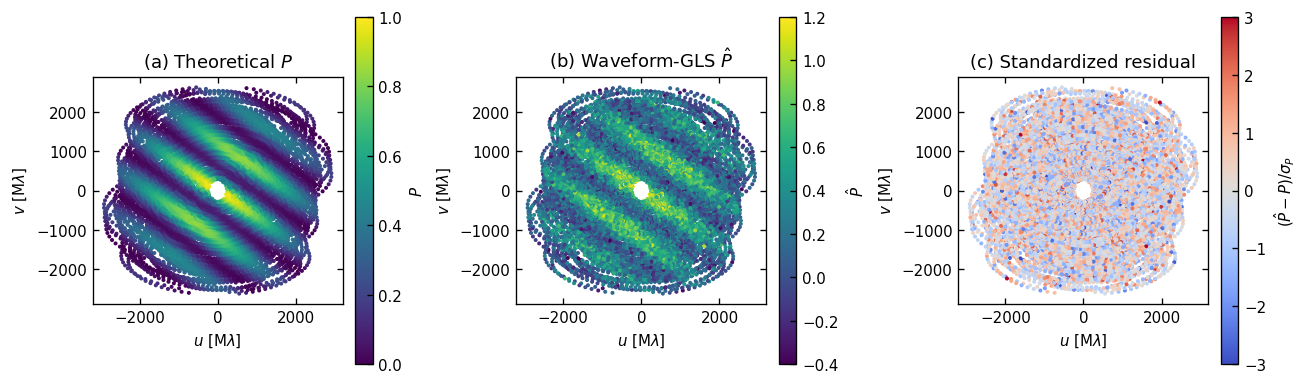

,Measurements,sigma_P per 20-min point,Residual mean,Residual standard deviation,"Raw estimates outside [0,1]"
0,8928,0.1742,-0.0087,1.0015,1300


In [7]:
reconstruction_kwargs = dict(
    grid_size=40, fov_mas=0.70, support_radius_mas=0.32,
    starts=3, max_iter=650, smoothness=0.020,
    huber_delta=0.15, peak_minimum_separation_mas=0.10)

reference_pipeline = run_sii_pipeline(
    layout, reference_source, reference_observation, instrument,
    seed=SEED + 100, estimator="waveform_gls",
    waveform_calibration=reference_calibration,
    reconstruction_kwargs=reconstruction_kwargs)
measured_uv = reference_pipeline.measurements

def symmetric_uv_scatter(axis, frame, values, cmap, norm, label):
    u = frame.u_lambda.to_numpy() / 1e6
    v = frame.v_lambda.to_numpy() / 1e6
    values = np.asarray(values)
    artist = axis.scatter(np.r_[u, -u], np.r_[v, -v], c=np.r_[values, values],
                          s=2.0, cmap=cmap, norm=norm, rasterized=True)
    axis.set(xlabel=r"$u$ [M$\lambda$]", ylabel=r"$v$ [M$\lambda$]")
    axis.set_aspect("equal")
    return artist

truth = measured_uv.visibility2_true.to_numpy()
measurement = measured_uv.visibility2_measured.to_numpy()
sigma = measured_uv.sigma_visibility2.to_numpy()
standardized_residual = (measurement - truth) / sigma

fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.1), constrained_layout=True)
artists = [
    symmetric_uv_scatter(axes[0], measured_uv, truth, "viridis", Normalize(0, 1), r"$P$"),
    symmetric_uv_scatter(axes[1], measured_uv, measurement, "viridis", Normalize(-0.4, 1.2), r"$\hat P$"),
    symmetric_uv_scatter(axes[2], measured_uv, standardized_residual, "coolwarm", TwoSlopeNorm(0, -3, 3), "Residual"),
]
for axis, title, artist, label in zip(
        axes, [r"(a) Theoretical $P$", r"(b) Waveform-GLS $\hat P$", "(c) Standardized residual"],
        artists, [r"$P$", r"$\hat P$", r"$(\hat P-P)/\sigma_P$"]):
    axis.set_title(title)
    fig.colorbar(artist, ax=axis, label=label)
fig.savefig(FIGURE_DIR / "13_waveform_gls_observed_uv.png", bbox_inches="tight")
plt.show()

uv_diagnostics = pd.DataFrame([{
    "Measurements": len(measured_uv),
    "sigma_P per 20-min point": float(np.median(sigma)),
    "Residual mean": float(np.mean(standardized_residual)),
    "Residual standard deviation": float(np.std(standardized_residual, ddof=1)),
    "Raw estimates outside [0,1]": int(np.sum((measurement < 0) | (measurement > 1))),
}])
display(uv_diagnostics.round(4))

## 7. 不同观测时间的重建

重建器只接收带噪的 ​\(\hat P\)​、不确定度和UV坐标，不读取天体真值。显示时允许平移和180度镜像对齐，因为这两项本来就不能由可见度模平方唯一确定。下面是一组固定随机种子的代表性 realization，不等同于多次试验得到的检出概率。

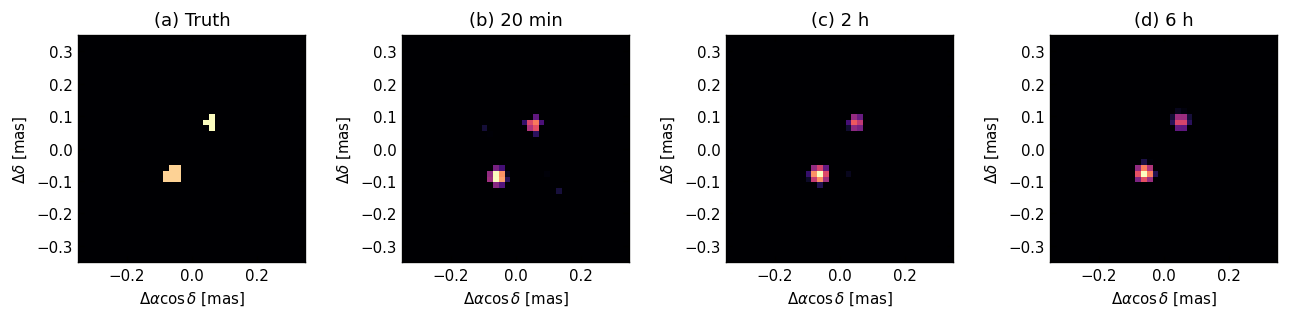

,Duration,UV measurements,Weighted visibility RMSE,Truth-image correlation,Recovered separation [mas]
0,20 min,496,0.1473,0.8670,0.2191
1,2 h,2976,0.0885,0.8736,0.1941
2,6 h,8928,0.0579,0.8883,0.1941


In [8]:
def align_for_display(image, truth_image):
    # 只为验证显示选择平移和180度镜像；不参与优化。
    best = None
    for candidate in (image, image[::-1, ::-1]):
        corr = np.fft.ifft2(np.fft.fft2(truth_image) * np.conj(np.fft.fft2(candidate))).real
        iy, ix = np.unravel_index(np.argmax(corr), corr.shape)
        sy = iy if iy <= image.shape[0] // 2 else iy - image.shape[0]
        sx = ix if ix <= image.shape[1] // 2 else ix - image.shape[1]
        aligned = np.roll(candidate, (sy, sx), axis=(0, 1))
        coefficient = np.corrcoef(aligned.ravel(), truth_image.ravel())[0, 1]
        if best is None or coefficient > best[0]:
            best = coefficient, aligned
    return best


# 从同一6小时 realization 中逐步增加中心时段，避免把随机差异误当时间趋势。
segment_order = (measured_uv[["segment", "hour_angle_h"]].drop_duplicates()
                 .assign(abs_hour_angle=lambda frame: frame.hour_angle_h.abs())
                 .sort_values(["abs_hour_angle", "hour_angle_h"]))
selected_segment_counts = {"20 min": 1, "2 h": 6, "6 h": 18}
time_measurements = {}
time_reconstructions = {}
for label, count in selected_segment_counts.items():
    segment_ids = segment_order.head(count).segment.to_numpy()
    subset = measured_uv.loc[measured_uv.segment.isin(segment_ids)].copy()
    time_measurements[label] = subset
    time_reconstructions[label] = reconstruct_uv(
        subset, seed=SEED + 120 + count, **reconstruction_kwargs)

theta_reco = reference_pipeline.reconstruction.theta_mas
truth_reco = sky_image("binary", reference_source, theta_reco)
extent_reco = [theta_reco[0], theta_reco[-1], theta_reco[0], theta_reco[-1]]

fig, axes = plt.subplots(1, 4, figsize=(10.8, 2.55), constrained_layout=True)
axes[0].imshow(truth_reco, origin="lower", extent=extent_reco, cmap="magma")
axes[0].set_title("(a) Truth")
time_rows = []
for panel, label in enumerate(["20 min", "2 h", "6 h"], start=1):
    reconstruction = time_reconstructions[label]
    correlation, aligned = align_for_display(reconstruction.image, truth_reco)
    axes[panel].imshow(aligned, origin="lower", extent=extent_reco, cmap="magma")
    axes[panel].set_title(f"({chr(97+panel)}) {label}")
    metrics = reconstruction.metrics
    time_rows.append({
        "Duration": label, "UV measurements": len(time_measurements[label]),
        "Weighted visibility RMSE": metrics["weighted_fit_rmse"],
        "Truth-image correlation": correlation,
        "Recovered separation [mas]": metrics.get("two_peak_separation_mas", np.nan),
    })
for axis in axes:
    axis.set(xlabel=r"$\Delta\alpha\cos\delta$ [mas]", ylabel=r"$\Delta\delta$ [mas]")
    axis.set_aspect("equal")
fig.savefig(FIGURE_DIR / "14_reconstruction_vs_time.png", bbox_inches="tight")
plt.show()
display(pd.DataFrame(time_rows).round(4))

### 7.1 不同观测时间对应的实际 UV 平面

三幅图使用相同的颜色范围，并且数据严格嵌套。20分钟只有一个中心时间段的496条基线；2小时和6小时依次加入更多时间段。这里显示的是波形GLS直接给出的带噪 \(\hat P\)，不是理论真值。

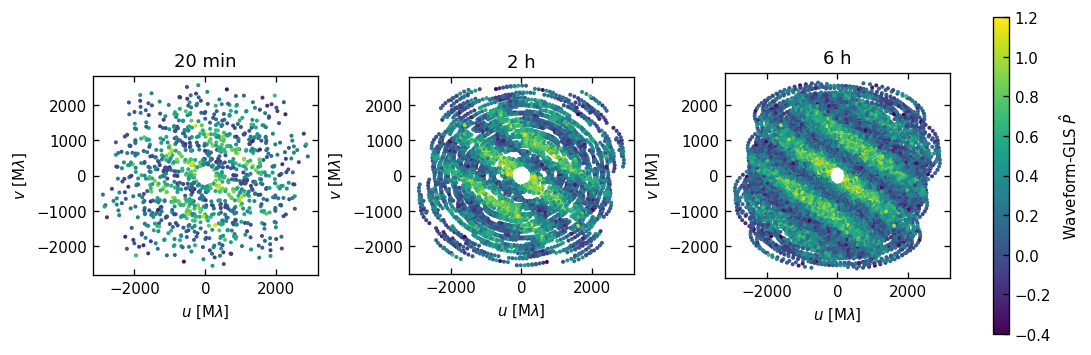

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(9.0, 2.85), constrained_layout=True)
time_uv_artist = None
for axis, label in zip(axes, ["20 min", "2 h", "6 h"]):
    frame = time_measurements[label]
    time_uv_artist = symmetric_uv_scatter(
        axis, frame, frame.visibility2_measured,
        "viridis", Normalize(-0.4, 1.2), r"$\hat P$")
    axis.set_title(label)
fig.colorbar(time_uv_artist, ax=axes, label=r"Waveform-GLS $\hat P$")
fig.savefig(FIGURE_DIR / "17_observed_uv_vs_time.png", bbox_inches="tight")
plt.show()

## 8. 较暗双星随观测时间的重建

为检验亮源20分钟结果是否过于乐观，本节把总亮度降为 \(m_{\rm AB}=4\)，并使用该星等独立标定的波形响应。20分钟、2小时和6小时仍取自同一个6小时 realization。它用于展示过渡行为，不替代多随机种子检出概率。

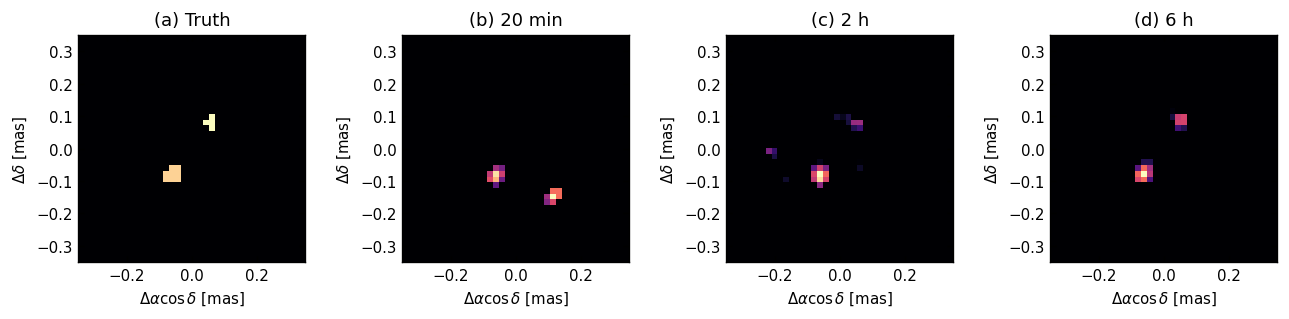

,Duration,UV measurements,Weighted visibility RMSE,Truth-image correlation,Recovered separation [mas]
0,20 min,496,2.4119,0.5123,0.1933
1,2 h,2976,1.7293,0.8285,0.2046
2,6 h,8928,1.2064,0.8820,0.2191


In [10]:
faint_source = replace(reference_source, ab_magnitude=4.0)
faint_pipeline_6h = run_sii_pipeline(
    layout, faint_source, reference_observation, instrument,
    seed=SEED + 204, estimator="waveform_gls",
    waveform_calibration=calibrations[4.0],
    reconstruction_kwargs=reconstruction_kwargs)

faint_time_measurements = {}
faint_time_reconstructions = {}
for label, count in selected_segment_counts.items():
    segment_ids = segment_order.head(count).segment.to_numpy()
    subset = faint_pipeline_6h.measurements.loc[
        faint_pipeline_6h.measurements.segment.isin(segment_ids)].copy()
    faint_time_measurements[label] = subset
    faint_time_reconstructions[label] = reconstruct_uv(
        subset, seed=SEED + 520 + count, **reconstruction_kwargs)

fig, axes = plt.subplots(1, 4, figsize=(10.8, 2.55), constrained_layout=True)
axes[0].imshow(truth_reco, origin="lower", extent=extent_reco, cmap="magma")
axes[0].set_title("(a) Truth")
faint_time_rows = []
for panel, label in enumerate(["20 min", "2 h", "6 h"], start=1):
    reconstruction = faint_time_reconstructions[label]
    correlation, aligned = align_for_display(reconstruction.image, truth_reco)
    axes[panel].imshow(aligned, origin="lower", extent=extent_reco, cmap="magma")
    axes[panel].set_title(f"({chr(97 + panel)}) {label}")
    metrics = reconstruction.metrics
    faint_time_rows.append({
        "Duration": label,
        "UV measurements": len(faint_time_measurements[label]),
        "Weighted visibility RMSE": metrics["weighted_fit_rmse"],
        "Truth-image correlation": correlation,
        "Recovered separation [mas]": metrics.get("two_peak_separation_mas", np.nan),
    })
for axis in axes:
    axis.set(xlabel=r"$\Delta\alpha\cos\delta$ [mas]",
             ylabel=r"$\Delta\delta$ [mas]")
    axis.set_aspect("equal")
fig.savefig(FIGURE_DIR / "18_faint_m4_reconstruction_vs_time.png", bbox_inches="tight")
plt.show()
display(pd.DataFrame(faint_time_rows).round(4))

## 9. 不同星等的重建

星等改变恒星光子率，也会改变波形相关峰相对于NSB散粒噪声的强度。因此每个星等都独立生成短波形标定，而不是复用2等星的不确定度。这里比较2至5等星在同一6小时几何覆盖下的一次模拟结果。

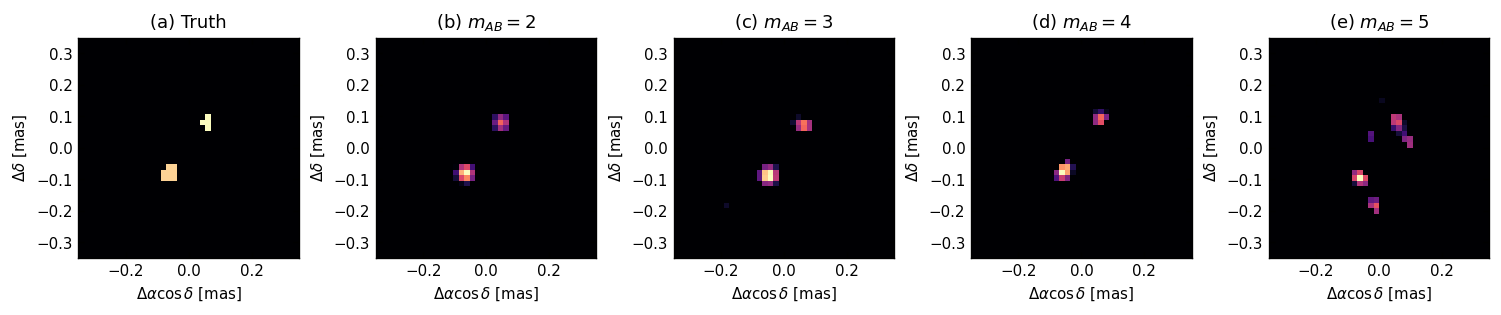

,m_AB,sigma_P per 20-min point,Weighted visibility RMSE,Truth-image correlation,Recovered separation [mas],Delta BIC (single - binary)
0,2.0,0.1742,0.0580,0.8345,0.1941,28006.8965
1,3.0,0.6387,0.2211,0.7698,0.2093,1839.6227
2,4.0,2.7135,1.2057,0.8452,0.2191,100.3468
3,5.0,13.5773,6.8968,0.6245,0.1047,-5.7670


In [11]:
magnitude_pipelines = {2.0: reference_pipeline, 4.0: faint_pipeline_6h}
for magnitude in (3.0, 5.0):
    source = replace(reference_source, ab_magnitude=magnitude)
    magnitude_pipelines[magnitude] = run_sii_pipeline(
        layout, source, reference_observation, instrument,
        seed=SEED + 200 + int(magnitude), estimator="waveform_gls",
        waveform_calibration=calibrations[magnitude],
        reconstruction_kwargs=reconstruction_kwargs)

fig, axes = plt.subplots(1, 5, figsize=(12.4, 2.45), constrained_layout=True)
axes[0].imshow(truth_reco, origin="lower", extent=extent_reco, cmap="magma")
axes[0].set_title("(a) Truth")
magnitude_rows = []
for panel, magnitude in enumerate((2.0, 3.0, 4.0, 5.0), start=1):
    pipeline = magnitude_pipelines[magnitude]
    correlation, aligned = align_for_display(pipeline.reconstruction.image, truth_reco)
    axes[panel].imshow(aligned, origin="lower", extent=extent_reco, cmap="magma")
    axes[panel].set_title(f"({chr(97+panel)}) $m_{{AB}}={magnitude:.0f}$")
    metrics = pipeline.reconstruction.metrics
    magnitude_rows.append({
        "m_AB": magnitude,
        "sigma_P per 20-min point": pipeline.metadata["sigma_visibility2_total"],
        "Weighted visibility RMSE": metrics["weighted_fit_rmse"],
        "Truth-image correlation": correlation,
        "Recovered separation [mas]": metrics.get("two_peak_separation_mas", np.nan),
    })

# 用参数化双星和单星圆盘的BIC差判断双峰是否由数据支持。
def binary_vs_single_delta_bic(pipeline, magnitude):
    frame = pipeline.measurements
    observed = frame.visibility2_measured.to_numpy()
    sigma = frame.sigma_visibility2.to_numpy()
    observation = reference_observation

    def chi2_binary(parameters):
        separation, position_angle, flux_ratio = parameters
        trial = replace(reference_source, ab_magnitude=magnitude,
                        separation_mas=separation,
                        position_angle_deg=position_angle,
                        flux_ratio_secondary_to_primary=flux_ratio)
        prediction = segment_averaged_visibility2(
            frame, trial, observation, instrument, "binary")
        return np.sum(((observed - prediction) / sigma) ** 2)

    def chi2_single(parameters):
        trial = replace(reference_source, ab_magnitude=magnitude,
                        primary_diameter_mas=float(parameters[0]))
        prediction = segment_averaged_visibility2(
            frame, trial, observation, instrument, "single_disk")
        return np.sum(((observed - prediction) / sigma) ** 2)

    binary_fit = minimize(
        chi2_binary, [0.20, 35.0, 0.55], method="L-BFGS-B",
        bounds=[(0.02, 0.40), (0.0, 180.0), (0.05, 1.0)])
    single_fit = minimize(
        chi2_single, [0.10], method="L-BFGS-B", bounds=[(0.01, 0.50)])
    n = len(frame)
    bic_binary = binary_fit.fun + 3 * np.log(n)
    bic_single = single_fit.fun + np.log(n)
    return bic_single - bic_binary

for row in magnitude_rows:
    row["Delta BIC (single - binary)"] = binary_vs_single_delta_bic(
        magnitude_pipelines[row["m_AB"]], row["m_AB"])
for axis in axes:
    axis.set(xlabel=r"$\Delta\alpha\cos\delta$ [mas]", ylabel=r"$\Delta\delta$ [mas]")
    axis.set_aspect("equal")
fig.savefig(FIGURE_DIR / "15_reconstruction_vs_magnitude.png", bbox_inches="tight")
plt.show()
display(pd.DataFrame(magnitude_rows).round(4))

### 9.1 不同星等对应的实际 UV 显著性平面

原始 \(\hat P\) 的噪声尺度随星等跨越近两个数量级，直接使用同一线性色标会隐藏亮源结构。下面统一显示每个测量的 \(\hat P/\sigma_P\)，色标范围完全相同；超过范围的点只在显示中饱和，数据没有裁剪。

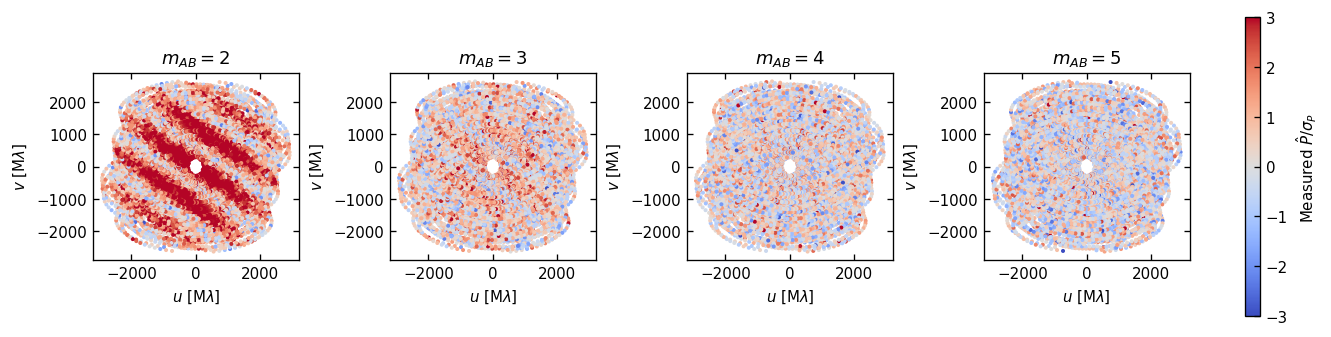

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(11.0, 2.7), constrained_layout=True)
magnitude_uv_artist = None
for axis, magnitude in zip(axes, [2.0, 3.0, 4.0, 5.0]):
    frame = magnitude_pipelines[magnitude].measurements
    significance = frame.visibility2_measured / frame.sigma_visibility2
    magnitude_uv_artist = symmetric_uv_scatter(
        axis, frame, significance, "coolwarm",
        TwoSlopeNorm(vcenter=0.0, vmin=-3.0, vmax=3.0),
        r"$\hat P/\sigma_P$")
    axis.set_title(rf"$m_{{AB}}={magnitude:.0f}$")
fig.colorbar(magnitude_uv_artist, ax=axes, label=r"Measured $\hat P/\sigma_P$")
fig.savefig(FIGURE_DIR / "19_observed_uv_vs_magnitude.png", bbox_inches="tight")
plt.show()

## 10. 双星、均匀椭圆与凌日模型

三种源使用相同的总AB星等、阵列、单夜6小时观测和波形标定。每行依次给出天体真值、连续理论 ​\(|V|^2\)​ 和从带噪测量得到的无模型重建。凌日模型采用完全位于均匀恒星盘内的不透明圆盘，是方法检验模型，不包含临边昏暗。

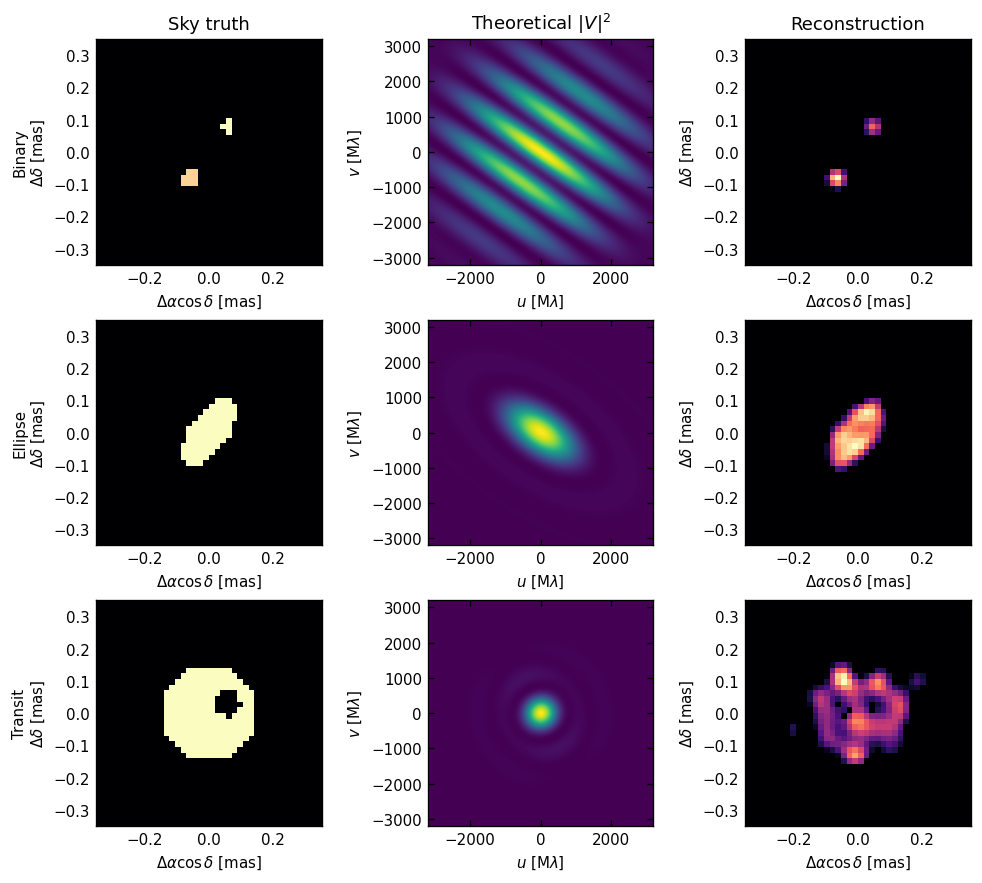

,Model,Weighted visibility RMSE,Truth-image correlation,Optimizer success
0,Binary,0.0580,0.8345,True
1,Ellipse,0.0577,0.9416,True
2,Transit,0.0583,0.8415,True


In [13]:
model_sources = {
    "Binary": ("binary", reference_source),
    "Ellipse": ("ellipse", EllipseSource(ab_magnitude=2.0)),
    "Transit": ("transit", TransitSource(ab_magnitude=2.0)),
}
model_pipelines = {"Binary": reference_pipeline}
for index, (name, (source_case, source)) in enumerate(model_sources.items()):
    if name == "Binary":
        continue
    model_pipelines[name] = run_sii_pipeline(
        layout, source, reference_observation, instrument,
        seed=SEED + 300 + index, estimator="waveform_gls",
        waveform_calibration=reference_calibration, source_case=source_case,
        reconstruction_kwargs=reconstruction_kwargs)

fig, axes = plt.subplots(3, 3, figsize=(8.2, 7.25), constrained_layout=True)
model_rows = []
for row, (name, (source_case, source)) in enumerate(model_sources.items()):
    truth_image = sky_image(source_case, source, theta_reco)
    uv_axis_model, theory_power = power_grid(source_case, source, uv_limit, points=241)
    pipeline = model_pipelines[name]
    correlation, aligned = align_for_display(pipeline.reconstruction.image, truth_image)
    axes[row, 0].imshow(truth_image, origin="lower", extent=extent_reco, cmap="magma")
    axes[row, 1].imshow(theory_power, origin="lower",
        extent=[uv_axis_model[0], uv_axis_model[-1], uv_axis_model[0], uv_axis_model[-1]],
        cmap="viridis", vmin=0, vmax=1)
    axes[row, 2].imshow(aligned, origin="lower", extent=extent_reco, cmap="magma")
    axes[row, 0].set_ylabel(f"{name}\n" + r"$\Delta\delta$ [mas]")
    model_rows.append({
        "Model": name,
        "Weighted visibility RMSE": pipeline.reconstruction.metrics["weighted_fit_rmse"],
        "Truth-image correlation": correlation,
        "Optimizer success": pipeline.reconstruction.metrics["optimizer_success"],
    })
for col, title in enumerate(["Sky truth", r"Theoretical $|V|^2$", "Reconstruction"]):
    axes[0, col].set_title(title)
for row in range(3):
    axes[row, 0].set_xlabel(r"$\Delta\alpha\cos\delta$ [mas]")
    axes[row, 1].set_xlabel(r"$u$ [M$\lambda$]")
    axes[row, 1].set_ylabel(r"$v$ [M$\lambda$]")
    axes[row, 2].set_xlabel(r"$\Delta\alpha\cos\delta$ [mas]")
    axes[row, 2].set_ylabel(r"$\Delta\delta$ [mas]")
    for col in range(3):
        axes[row, col].set_aspect("equal")
fig.savefig(FIGURE_DIR / "16_reconstruction_source_models.png", bbox_inches="tight")
plt.show()
display(pd.DataFrame(model_rows).round(4))

## 11. 参数影响汇总

下表报告单个20分钟UV测量的 ​\(\sigma_P\)​。曝光时间行由同一标定协方差按 ​\(T^{-1/2}\)​ 精确缩放；星等、NSB、光学时间核、SPE形状和采样间隔行均重新运行波形标定。它衡量单点精度，不直接等于整个图像的检出显著性。

In [14]:
# 为每个仪器变化重新生成波形模板与零信号协方差。
variant_calibrations = {}
variant_calibrations["No NSB"] = simulate_waveform_gls_calibration(
    instrument, source_ab_magnitude=2.0, nsb_rate_hz=0.0,
    null_records=1024, signal_records=256, hbt_pair_rate_scale=10_000,
    seed=SEED + 401)[0]
no_timing_instrument = replace(instrument, optical_timing_kernel_path=None)
variant_calibrations["No optical spread"] = simulate_waveform_gls_calibration(
    no_timing_instrument, source_ab_magnitude=2.0,
    null_records=1024, signal_records=256, hbt_pair_rate_scale=10_000,
    seed=SEED + 402)[0]
fast_template = make_fast_spe_template(
    rise_ns=0.4, fall_ns=2.0, support_ns=10.0, step_ns=0.02)
variant_calibrations["10 ns SPE support"] = simulate_waveform_gls_calibration(
    instrument, source_ab_magnitude=2.0, spe_template=fast_template,
    null_records=1024, signal_records=256, hbt_pair_rate_scale=10_000,
    seed=SEED + 403)[0]
one_ns_instrument = replace(
    instrument, adc_sample_rate_hz=1.0e9,
    electronics_bandwidth_hz=500.0e6)
variant_calibrations["1 ns sampling"] = simulate_waveform_gls_calibration(
    one_ns_instrument, source_ab_magnitude=2.0,
    null_records=1024, signal_records=256, hbt_pair_rate_scale=10_000,
    seed=SEED + 404)[0]

reference_sigma = waveform_gls_weights(reference_calibration, 1200.0)[1]
parameter_rows = [
    ("Reference", "m_AB=2, 20 min, measured SPE", reference_sigma, "waveform calibration"),
    ("Exposure", "10 min", waveform_gls_weights(reference_calibration, 600.0)[1], "T^-1/2 scaling"),
    ("Exposure", "60 min", waveform_gls_weights(reference_calibration, 3600.0)[1], "T^-1/2 scaling"),
    ("Magnitude", "m_AB=3", waveform_gls_weights(calibrations[3.0], 1200.0)[1], "independent calibration"),
    ("Magnitude", "m_AB=4", waveform_gls_weights(calibrations[4.0], 1200.0)[1], "independent calibration"),
    ("Magnitude", "m_AB=5", waveform_gls_weights(calibrations[5.0], 1200.0)[1], "independent calibration"),
]
for label, calibration in variant_calibrations.items():
    parameter_rows.append(("Instrument", label,
                           waveform_gls_weights(calibration, 1200.0)[1],
                           "independent calibration"))
parameter_table = pd.DataFrame(
    parameter_rows, columns=["Parameter", "Setting", "sigma_P", "Method"])
parameter_table["Relative SNR"] = reference_sigma / parameter_table["sigma_P"]
display(parameter_table.round(4))

,Parameter,Setting,sigma_P,Method,Relative SNR
0,Reference,"m_AB=2, 20 min, measured SPE",0.1742,waveform calibration,1.0000
1,Exposure,10 min,0.2464,T^-1/2 scaling,0.7071
2,Exposure,60 min,0.1006,T^-1/2 scaling,1.7321
3,Magnitude,m_AB=3,0.6387,independent calibration,0.2728
4,Magnitude,m_AB=4,2.7135,independent calibration,0.0642
5,Magnitude,m_AB=5,13.5773,independent calibration,0.0128
6,Instrument,No NSB,0.1240,independent calibration,1.4055
7,Instrument,No optical spread,0.1727,independent calibration,1.0090
8,Instrument,10 ns SPE support,0.1289,independent calibration,1.3516
9,Instrument,1 ns sampling,0.1524,independent calibration,1.1437


## 12. 数值闭合检查与结论

本节只检查模拟链内部是否自洽，不把缺失的真实硬件系统误差解释为已解决。标准化残差应接近零均值、单位标准差；波形模板注入回收应接近1；曝光时间不确定度应满足 ​\(T^{-1/2}\)​。

In [15]:
checks = {
    "32 telescopes": len(layout) == 32,
    "496 independent baselines": layout.shape[0] * (layout.shape[0] - 1) // 2 == 496,
    "6 h has 8928 measurements": len(measured_uv) == 8928,
    "waveform response closure within 10%": abs(calibration_diagnostics[2.0]["validation_response_closure"] - 1) < 0.10,
    "standardized residual mean within 0.05": abs(np.mean(standardized_residual)) < 0.05,
    "standardized residual std within 5%": abs(np.std(standardized_residual, ddof=1) - 1) < 0.05,
    "T^-1/2 uncertainty scaling": np.isclose(
        waveform_gls_weights(reference_calibration, 4800.0)[1], reference_sigma / 2),
    "all reconstructions used noisy measurements": all(
        not np.allclose(frame.visibility2_measured, frame.visibility2_true)
        for frame in list(time_measurements.values())
        + [p.measurements for p in magnitude_pipelines.values()]
        + [p.measurements for p in model_pipelines.values()]),
}
check_table = pd.DataFrame({"Check": checks.keys(), "Passed": checks.values()})
display(check_table)
assert all(checks.values())

print("结论：完整波形GLS链在当前已知参数下通过闭合检查。")
print("限制：共享电子噪声、ADC量化、长期增益/时钟漂移仍因缺少实测标定而关闭。")
print("不同时间和星等图是单次固定随机实现；正式极限应使用多随机种子检出概率研究。")

,Check,Passed
0,32 telescopes,True
1,496 independent baselines,True
2,6 h has 8928 measurements,True
3,waveform response closure within 10%,True
4,standardized residual mean within 0.05,True
5,standardized residual std within 5%,True
6,T^-1/2 uncertainty scaling,True
7,all reconstructions used noisy measurements,True


结论：完整波形GLS链在当前已知参数下通过闭合检查。
限制：共享电子噪声、ADC量化、长期增益/时钟漂移仍因缺少实测标定而关闭。
不同时间和星等图是单次固定随机实现；正式极限应使用多随机种子检出概率研究。
